In [78]:
#importing the needed libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

In [79]:
df = pd.read_csv("./dataset/DM1_game_dataset_cleaned.csv")

df.columns

Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Category', 'Rank', 'EngagementLevel'],
      dtype='object')

## Preprocessing

In [102]:
#checking any missing values
cols = [
    'Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
    'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
    'NumImplementations', 'IsReimplementation', 'Kickstarted',
    'Rating', 'HasFamily', 'Category', 'Rank', 'EngagementLevel'
]

missing_df = (
    df[cols]
    .isna()
    .sum()
    .to_frame(name='MissingCount')
)

missing_df['MissingPercent'] = (missing_df['MissingCount'] / len(df)) * 100
missing_df = missing_df.sort_values(by='MissingPercent', ascending=False)

print(missing_df)


                    MissingCount  MissingPercent
Name                           0             0.0
NumImplementations             0             0.0
Rank                           0             0.0
Category                       0             0.0
HasFamily                      0             0.0
Rating                         0             0.0
Kickstarted                    0             0.0
IsReimplementation             0             0.0
NumExpansions                  0             0.0
YearPublished                  0             0.0
NumAlternates                  0             0.0
MfgAgeRec                      0             0.0
MfgPlaytime                    0             0.0
MaxPlayers                     0             0.0
MinPlayers                     0             0.0
GameWeight                     0             0.0
EngagementLevel                0             0.0


In [103]:
#looking for outliers and calculating skeweness 
from scipy.stats import skew

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

outlier_stats = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = outliers.count()
    outlier_pct = (outlier_count / df[col].count()) * 100
    
    outlier_stats.append([col, outlier_count, outlier_pct, IQR, lower_bound, upper_bound])

outliers_df = pd.DataFrame(outlier_stats, columns=[
    'Variable', 'OutlierCount', 'OutlierPercent', 'IQR', 'LowerBound', 'UpperBound'
]).sort_values(by='OutlierPercent', ascending=False)

print(outliers_df)

skewness_values = []

for col in numeric_cols:
    sk = skew(df[col].dropna())
    skewness_values.append([col, sk])

skew_df = pd.DataFrame(skewness_values, columns=['Variable', 'Skewness'])\
          .sort_values(by='Skewness', ascending=False)

print(skew_df)


              Variable  OutlierCount  OutlierPercent           IQR  \
2           MinPlayers          6848       31.299420      0.000000   
3           MaxPlayers          5462       24.964578      0.336472   
8   NumImplementations          4829       22.071393      0.000000   
10         Kickstarted          3339       15.261209      0.000000   
9   IsReimplementation          2530       11.563600      0.000000   
0        YearPublished          1141        5.215046     16.000000   
4          MfgPlaytime           504        2.303579      1.076872   
13     EngagementLevel           451        2.061337      1.900240   
7        NumExpansions           388        1.773390      0.526589   
6        NumAlternates           237        1.083230      0.526589   
1           GameWeight           150        0.685589      1.168000   
5            MfgAgeRec            14        0.063988      4.000000   
11           HasFamily             0        0.000000      1.000000   
12                Ra

In [104]:
#handling outliers with log transformations
log_transform_cols = [
    "MinPlayers",
    "NumImplementations",
    "NumAlternates",
    "NumExpansions",
    "MfgPlaytime",
    "MaxPlayers"
]

for col in log_transform_cols:
    df[col] = np.log1p(df[col])


In [105]:
#standardization
numeric_vars = [
    "GameWeight",
    "MinPlayers",        
    "MaxPlayers",        
    "MfgPlaytime",       
    "MfgAgeRec",
    "NumAlternates",     
    "NumExpansions",     
    "NumImplementations",
    "EngagementLevel"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df[numeric_vars])

scaled_numeric = pd.DataFrame(scaled_numeric, columns=numeric_vars, index=df.index)





In [84]:
#checking correlations

# correlation matrix
corr = scaled_numeric.corr()

corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ["var1", "var2", "corr"]

corr_pairs = corr_pairs[corr_pairs["var1"] < corr_pairs["var2"]]

#filtering meaningful correlations
significant_corr = corr_pairs[abs(corr_pairs["corr"]) > 0.3]\
                       .sort_values(by="corr", ascending=False)

significant_corr

#I would keep NumImplementations and IsReimplementation even if they are correlated, they are not redundant even if correlated
#same reasoning with GameWeight and MfgPlaytime


,var1,var2,corr
3,GameWeight,MfgPlaytime,0.695419
4,GameWeight,MfgAgeRec,0.482298
39,MfgAgeRec,MfgPlaytime,0.482251
78,EngagementLevel,NumExpansions,0.418888
77,EngagementLevel,NumAlternates,0.386237


## Ward Linkage Method

In [85]:
Z = linkage(scaled_numeric, method='ward')


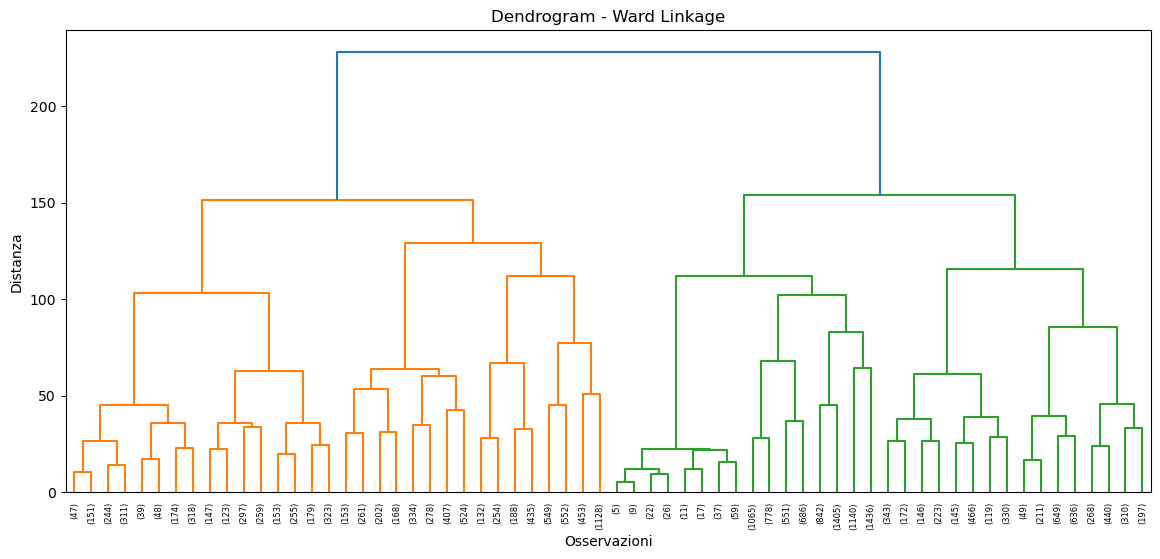

In [86]:
plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p=5 per rendere leggibile
plt.title("Dendrogram - Ward Linkage")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [35.0, 35.0, 45.0, 45.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [40.0, 40.0, 62.5, 62.5],
  [20.0, 20.0, 51.25, 51.25],
  [5.0, 5.0, 35.625, 35.625],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [85.0, 85.0, 102.5, 102.5],
  [125.0, 125.0, 135.0, 135.0],
  [165.0, 165.0, 175.0, 175.0],
  [155.0, 155.0, 170.0, 170.0],
  [145.0, 145.0, 162.5, 162.5],
  [205.0, 205.0, 215.0, 215.0],
  [195.0, 195.0, 210.0, 210.0],
  [185.0, 185.0, 202.5, 202.5],
  [153.75, 153.75, 193.75, 193.75],
  [130.0, 130.0, 173.75, 173.75],
  [93.75, 93.75, 151.875, 151.875],
  [20.3125, 20.3125, 122.8125, 122.8125],
  [225.0, 225.0, 235.0, 235.0],
  [275.0, 275.0, 285.0, 285.0],
  [265.0, 265.0, 280.0, 280.0],
  [255.0, 255.0, 272.5, 272.5],
  [295.0, 295.0, 305.0, 305.0],
  [263.75, 263.75, 300.0, 300.0],
  [245.0, 245.0, 281.875, 281.875],
  [230.0, 230.0, 263.4375, 263.4375],
  [315.0, 315.0, 325.0, 325.0],
  [355.0, 355.0, 365.0, 36

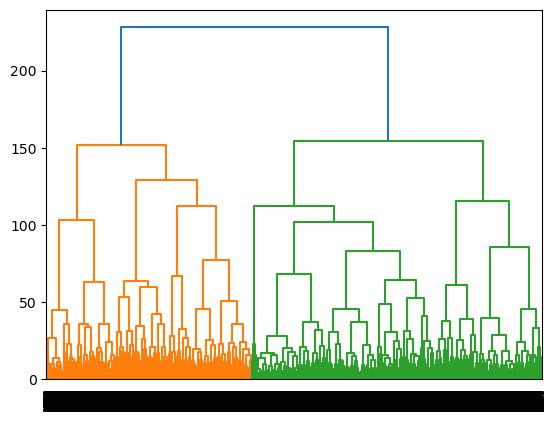

In [87]:
dendrogram(Z)


In [88]:
#silhouette coefficient
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 11):
    clusters_k = fcluster(Z, t=k, criterion='maxclust')
    score = silhouette_score(scaled_numeric, clusters_k)
    sil_scores[k] = score

sil_scores

{2: np.float64(0.14610953572182986),
 3: np.float64(0.08828703683543655),
 4: np.float64(0.08916815906752379),
 5: np.float64(0.10421958023537026),
 6: np.float64(0.10090844345633213),
 7: np.float64(0.10769265604616715),
 8: np.float64(0.11554220837598886),
 9: np.float64(0.10825339408907417),
 10: np.float64(0.080549225561847)}

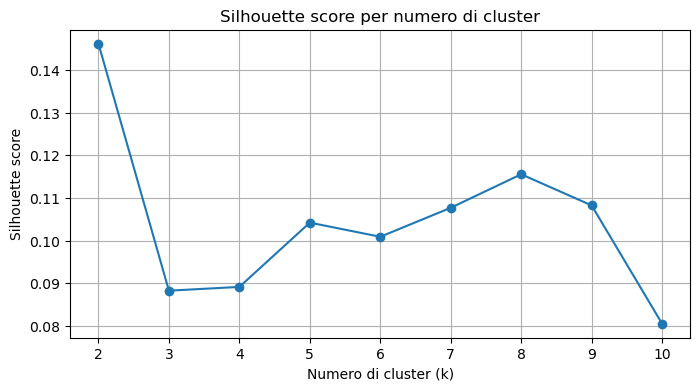

In [89]:
#silhouette graph
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.title("Silhouette score per numero di cluster")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [90]:
clusters = fcluster(Z, t=180, criterion='distance')
scaled_numeric["cluster"] = clusters
df["cluster"] = clusters

In [91]:
#counting how many games in each cluster
cluster_counts = scaled_numeric["cluster"].value_counts().sort_index()
cluster_counts

cluster
1     9086
2    12793
Name: count, dtype: int64

## Removing Outliers

In [106]:
# removing outliers in multidimensional space using percentile method
outlier_fraction = 0.30  # top 30% as outliers
dists = np.linalg.norm(scaled_numeric - scaled_numeric.mean(), axis=1) # Euclidean distance from the mean
threshold = np.percentile(dists, 100 * (1 - outlier_fraction)) # threshold distance
rows_to_remove = np.where(dists > threshold)[0] # indices of outlier rows
print(f"Number of rows to remove as outliers: {len(rows_to_remove)}")
scaled_numeric = scaled_numeric.drop(index=rows_to_remove).reset_index(drop=True)
len(scaled_numeric)

Number of rows to remove as outliers: 6564


15315

## Average Linkage Method

In [107]:
Z_avg = linkage(scaled_numeric, method='average')


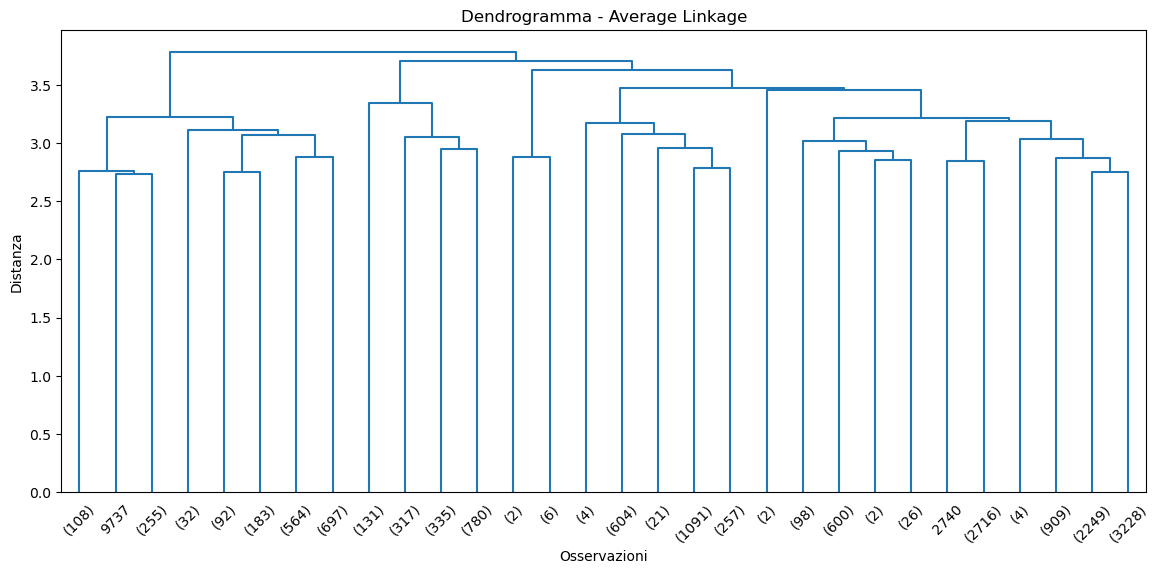

In [108]:


plt.figure(figsize=(14, 6))
dendrogram(Z_avg, truncate_mode='lastp')
plt.title("Dendrogramma - Average Linkage")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [109]:


sil_scores_avg = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_avg, t=k, criterion='maxclust')
    score = silhouette_score(scaled_numeric, clusters_k)
    sil_scores_avg[k] = score

sil_scores_avg


{2: np.float64(0.18216050802948108),
 3: np.float64(0.18448336632239926),
 4: np.float64(0.15205540858246938),
 5: np.float64(0.17167195563590884),
 6: np.float64(0.12928490618519498),
 7: np.float64(0.12347364833384868),
 8: np.float64(0.12377256174441495),
 9: np.float64(0.10963385312342352),
 10: np.float64(0.13837539287227688)}

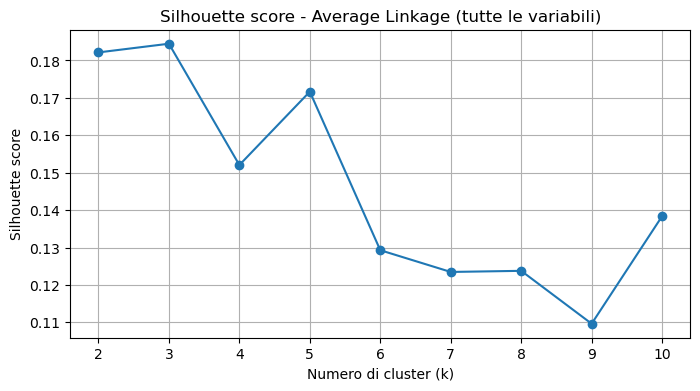

In [110]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_avg.keys()), list(sil_scores_avg.values()), marker='o')
plt.title("Silhouette score - Average Linkage (tutte le variabili)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [111]:
#assigning clusters, we choose number of clusters = 3
k_opt = 3
clusters = fcluster(Z_avg, t=k_opt, criterion='maxclust')

scaled_numeric["cluster_avg"] = clusters

In [112]:
#counting the number of games in each cluster
cluster_counts = scaled_numeric["cluster_avg"].value_counts().sort_index()
cluster_counts


cluster_avg
1     1932
2     1563
3    11820
Name: count, dtype: int64

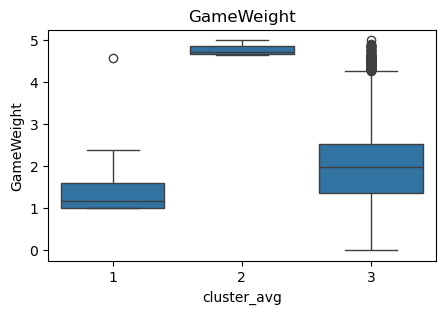

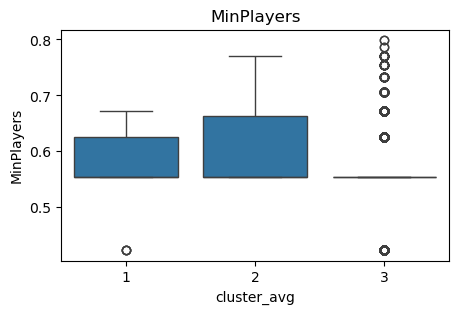

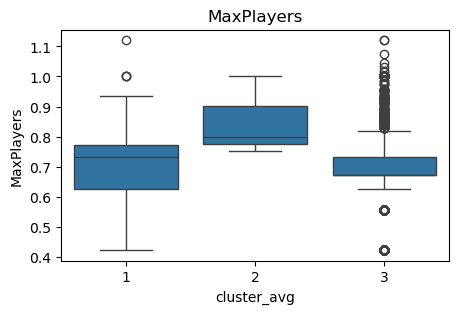

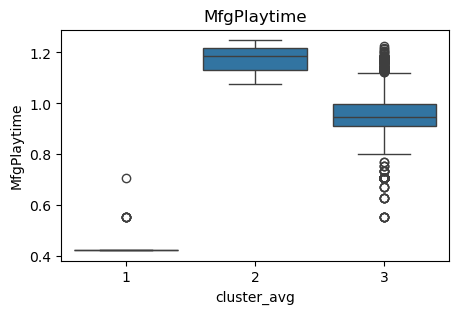

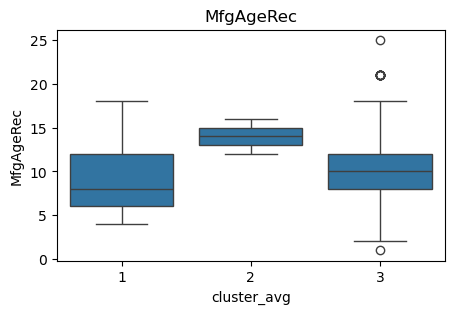

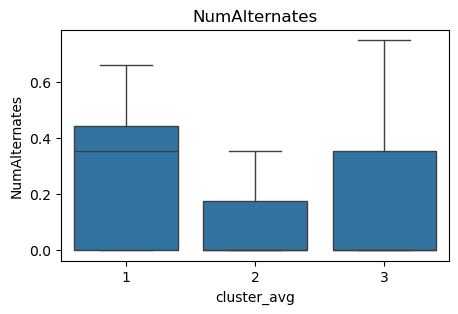

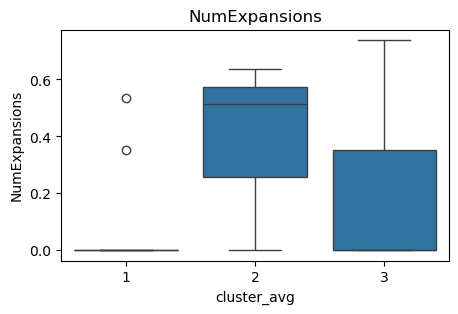

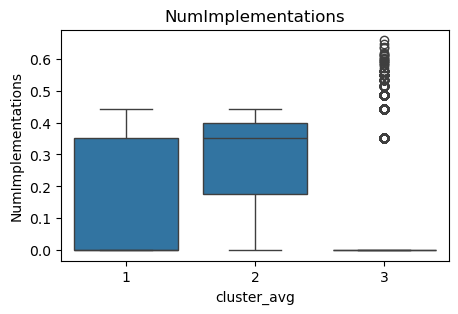

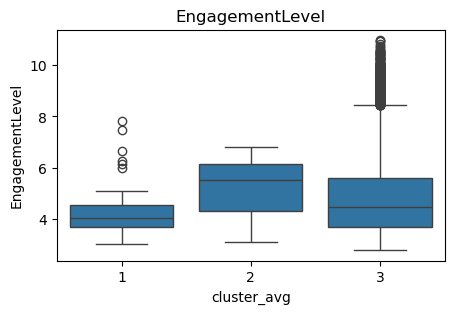

In [40]:

for col in numeric_vars:
    plt.figure(figsize=(5,3))
    sns.boxplot(x="cluster_avg", y=col, data=df)
    plt.title(col)
    plt.show()


## Complete Linkage

In [8]:

Z_comp = linkage(df_cluster, method='complete')


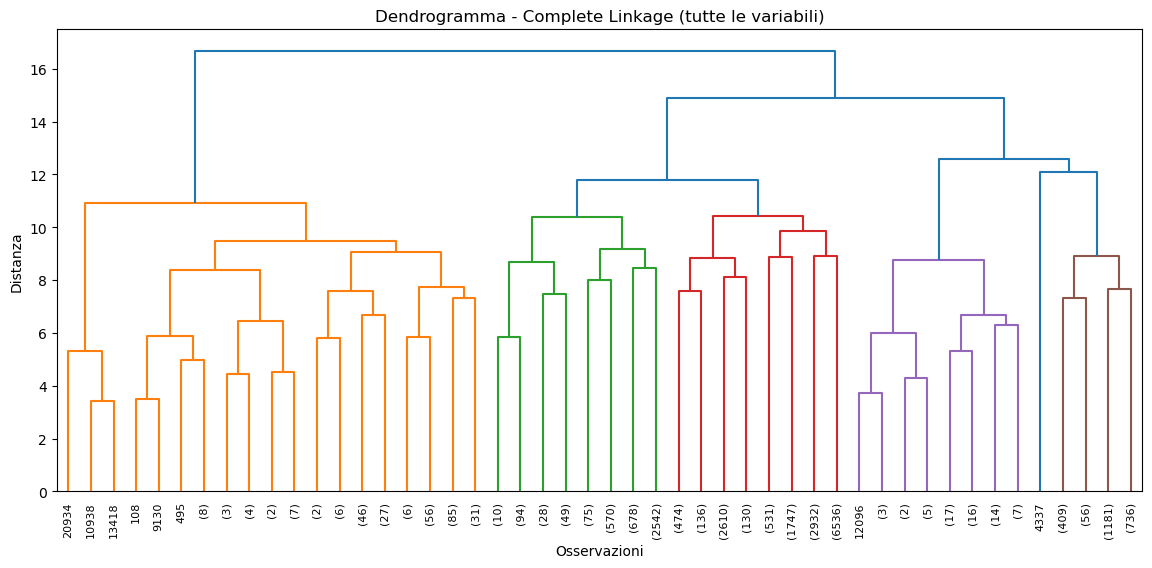

In [9]:

plt.figure(figsize=(14, 6))
dendrogram(Z_comp, truncate_mode='level', p=5)
plt.title("Dendrogramma - Complete Linkage (tutte le variabili)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [20]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

sil_scores_comp = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_comp, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster, clusters_k)
    sil_scores_comp[k] = score

sil_scores_comp


{2: np.float64(0.3691491518276166),
 3: np.float64(0.12946619429617898),
 4: np.float64(0.11838725861042955),
 5: np.float64(0.11789286063164803),
 6: np.float64(0.13315649142487654),
 7: np.float64(0.13278434212698445),
 8: np.float64(0.05984924256770368),
 9: np.float64(0.05529887844862978),
 10: np.float64(0.07638868026335517)}

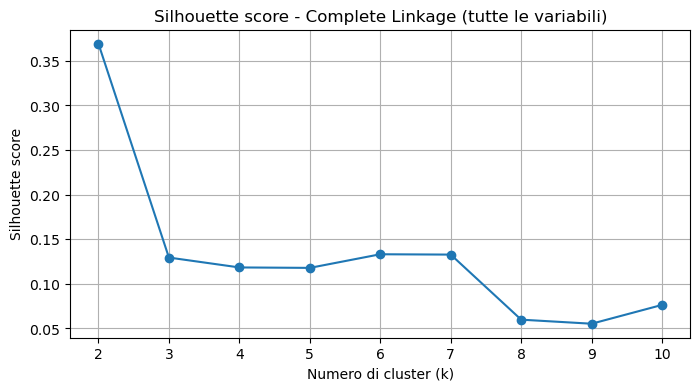

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_comp.keys()), list(sil_scores_comp.values()), marker='o')
plt.title("Silhouette score - Complete Linkage (tutte le variabili)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [22]:
#clusters assignation
clusters_2 = fcluster(Z_comp, t=2, criterion='maxclust')
df_cluster["cluster_comp_2"] = clusters_2
df["cluster_comp_2"] = clusters_2

In [24]:
df["cluster_comp_2"].value_counts()
#THIS IS STILL SOOO BAD! THESE ARE NOT CLUSTERS, BLOCK OF POINTS AND OUTLIERS...

cluster_comp_2
2    21590
1      289
Name: count, dtype: int64

In [25]:
#reasoning with only numerical columns
Z_num2 = linkage(df_cluster_num, method='complete')


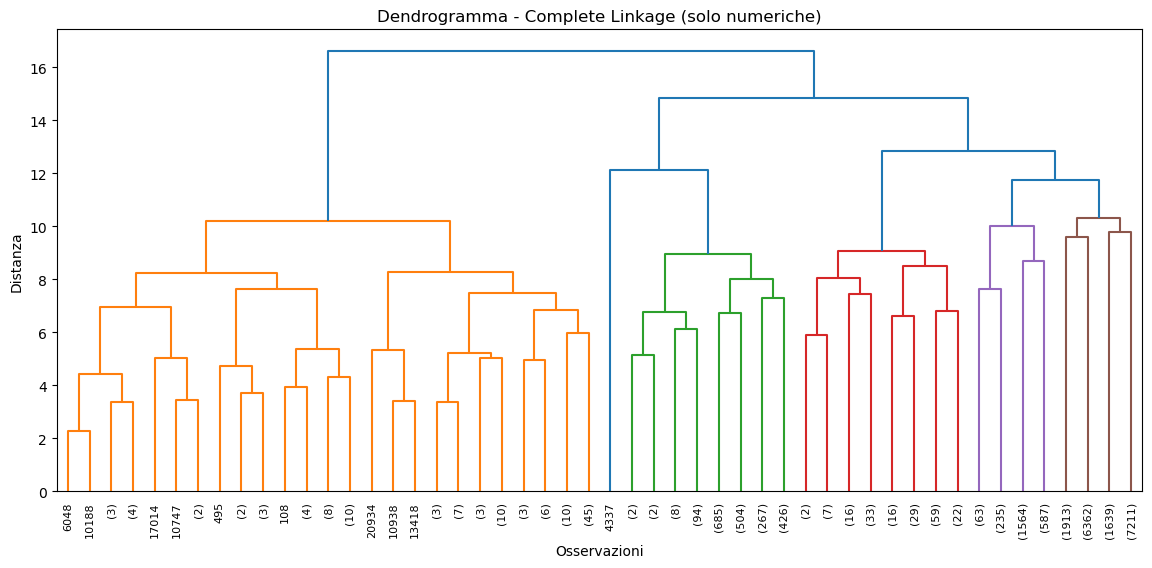

In [18]:

plt.figure(figsize=(14, 6))
dendrogram(Z_num2, truncate_mode='level', p=5)
plt.title("Dendrogramma - Complete Linkage (solo numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [26]:
from sklearn.metrics import silhouette_score

sil_scores_comp_num = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_num2, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_comp_num[k] = score

sil_scores_comp_num


{2: np.float64(0.46037154191568114),
 3: np.float64(0.15942198607734748),
 4: np.float64(0.1593539572416769),
 5: np.float64(0.15879725453786334),
 6: np.float64(0.11978962655865237),
 7: np.float64(0.07080525010832059),
 8: np.float64(0.06976726901559122),
 9: np.float64(0.06601927048862462),
 10: np.float64(0.050225270935058894)}

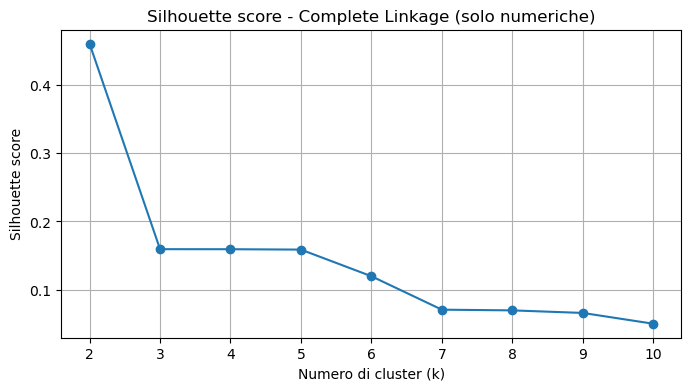

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_comp_num.keys()), list(sil_scores_comp_num.values()), marker='o')
plt.title("Silhouette score - Complete Linkage (solo numeriche)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [29]:
clusters_k2 = fcluster(Z_num2, t=2, criterion='maxclust')
pd.Series(clusters_k2).value_counts()
#THIS IS SOOOOO BAD STILL

2    21747
1      132
Name: count, dtype: int64

## Single Linkage

In [32]:
#considering first only numerical
Z_single = linkage(df_cluster_num, method='single')


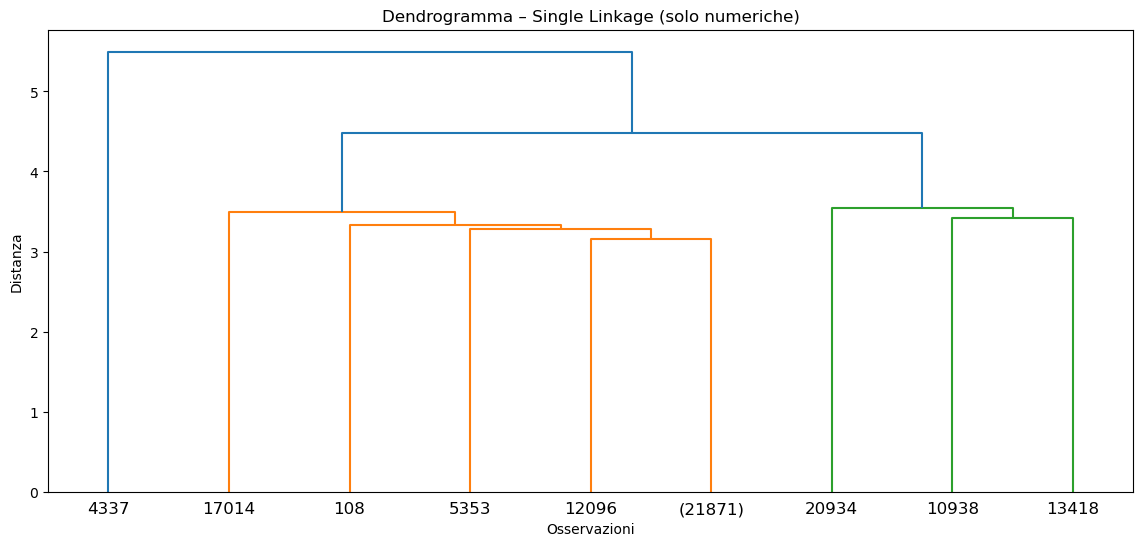

In [31]:
plt.figure(figsize=(14, 6))
dendrogram(Z_single, truncate_mode='level', p=5)
plt.title("Dendrogramma – Single Linkage (solo numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

sil_scores_single = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_single, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_single[k] = score

sil_scores_single


{2: np.float64(0.6224203927992886),
 3: np.float64(0.6090483130880116),
 4: np.float64(0.606018712642471),
 5: np.float64(0.5092562364674218),
 6: np.float64(0.5090844583542244),
 7: np.float64(0.5072333892716797),
 8: np.float64(0.32168848411620393),
 9: np.float64(0.31948342302028504),
 10: np.float64(0.3193027105569704)}

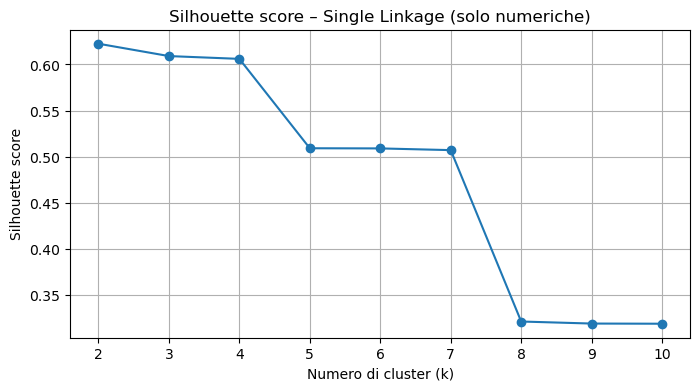

In [34]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_single.keys()), list(sil_scores_single.values()), marker='o')
plt.title("Silhouette score – Single Linkage (solo numeriche)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [35]:
clusters_single_2 = fcluster(Z_single, t=2, criterion='maxclust')
clusters_single_3 = fcluster(Z_single, t=3, criterion='maxclust')


In [37]:
print("Value counts k=2:")
print(pd.Series(clusters_single_2).value_counts())

print("\nValue counts k=3:")
print(pd.Series(clusters_single_3).value_counts())
#THIS IS SUUUUUOPER BAD.....USELESS!!!!!!!!


Value counts k=2:
1    21878
2        1
Name: count, dtype: int64

Value counts k=3:
1    21875
2        3
3        1
Name: count, dtype: int64


## Centroid Distance

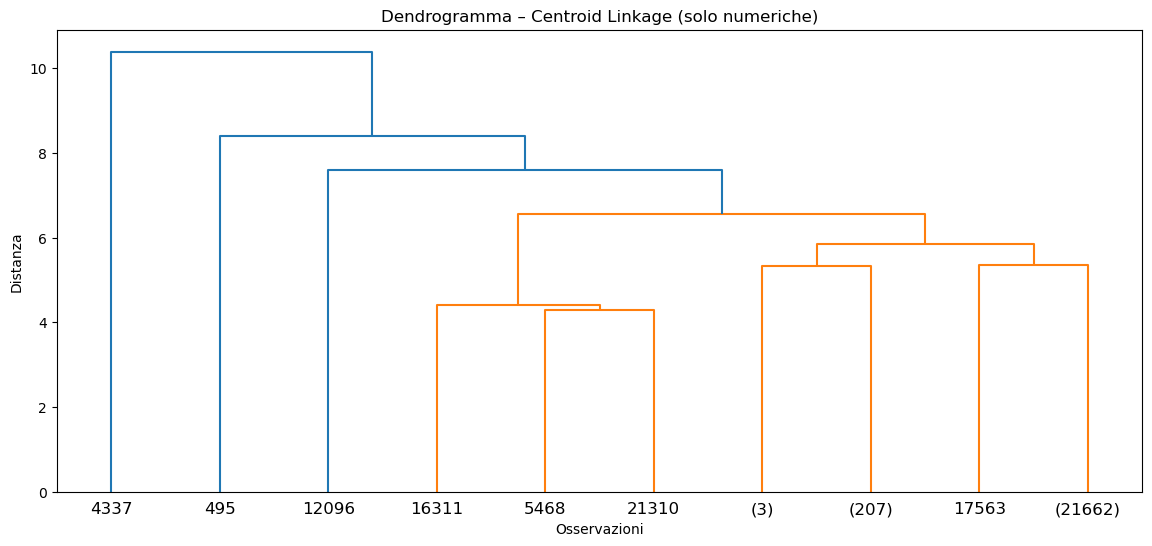

In [49]:
Z_centroid = linkage(df_cluster_num, method='centroid')

plt.figure(figsize=(14, 6))
dendrogram(Z_centroid, truncate_mode='level', p=5)
plt.title("Dendrogramma – Centroid Linkage (solo numeriche)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()

In [50]:
sil_scores_centroid = {}
for k in range(2, 11):
    clusters_k = fcluster(Z_centroid, t=k, criterion='maxclust')
    sil_scores_centroid[k] = silhouette_score(df_cluster_num, clusters_k)

sil_scores_centroid

{2: np.float64(0.6224203927992886),
 3: np.float64(0.5405074133350862),
 4: np.float64(0.47771393016625624),
 5: np.float64(0.41874093364422216),
 6: np.float64(0.39027976159383326),
 7: np.float64(0.30745900578765667),
 8: np.float64(0.3063961540617095),
 9: np.float64(0.2937836113101037),
 10: np.float64(0.2740124846424836)}

In [51]:
pd.Series(fcluster(Z_centroid, t=2, criterion='maxclust')).value_counts()
pd.Series(fcluster(Z_centroid, t=3, criterion='maxclust')).value_counts()

1    21877
2        1
3        1
Name: count, dtype: int64

## Let's try to change the kind of distance used --> Manhattan Distance

In [40]:
from scipy.spatial.distance import pdist



In [41]:
#still working only with numerical variables
D_manh = pdist(df_cluster_num, metric='cityblock')


In [42]:
#complete linkage with Manhattan Distance
Z_manh_complete = linkage(D_manh, method='complete')


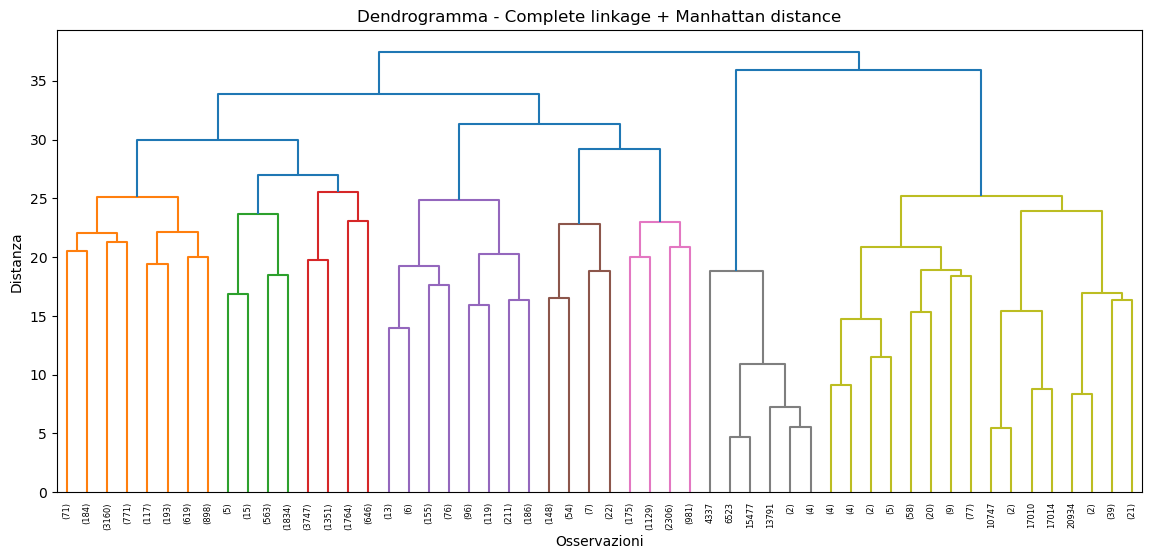

In [43]:
plt.figure(figsize=(14,6))
dendrogram(Z_manh_complete, truncate_mode='level', p=5)
plt.title("Dendrogramma - Complete linkage + Manhattan distance")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [44]:
from sklearn.metrics import silhouette_score

sil_scores_manh = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_manh_complete, t=k, criterion='maxclust')
    score = silhouette_score(df_cluster_num, clusters_k)
    sil_scores_manh[k] = score

sil_scores_manh


{2: np.float64(0.39957272596302484),
 3: np.float64(0.3178351681985586),
 4: np.float64(0.12561486861576746),
 5: np.float64(0.10880246166519204),
 6: np.float64(0.0858752531725077),
 7: np.float64(0.07903011740069028),
 8: np.float64(0.048260197625644645),
 9: np.float64(0.044891981681913516),
 10: np.float64(0.04330647050376709)}

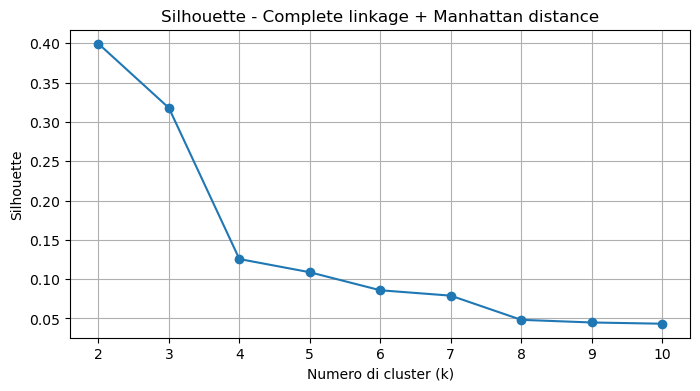

In [45]:
plt.figure(figsize=(8,4))
plt.plot(list(sil_scores_manh.keys()), list(sil_scores_manh.values()), marker='o')
plt.title("Silhouette - Complete linkage + Manhattan distance")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

In [ ]:
clusters_manh_2 = fcluster(Z_manh_complete, t=2, criterion='maxclust')
pd.Series(clusters_manh_2).value_counts()
#SUPER BAD


1    21622
2      257
Name: count, dtype: int64

In [48]:
clusters_manh_3 = fcluster(Z_manh_complete, t=3, criterion='maxclust')
pd.Series(clusters_manh_3).value_counts()
#SUPER BAD


1    21622
3      247
2       10
Name: count, dtype: int64

## Changing the Preprocessing - We eliminate more outliers

In [52]:
numeric_vars = [
    "GameWeight",
    "MinPlayers",
    "MaxPlayers",
    "MfgPlaytime",
    "MfgAgeRec",
    "NumAlternates",
    "NumExpansions",
    "NumImplementations",
    "EngagementLevel"
]

num_df = df[numeric_vars]

outlier_bounds = {}
outlier_percent = {}

for col in numeric_vars:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (num_df[col] < lower) | (num_df[col] > upper)
    outlier_percent[col] = mask.mean() * 100
    outlier_bounds[col] = (lower, upper)

outliers_summary = (
    pd.DataFrame({"Variable": list(outlier_percent.keys()),
                  "OutlierPercent": list(outlier_percent.values())})
    .sort_values("OutlierPercent", ascending=False)
)

print(outliers_summary)

             Variable  OutlierPercent
1          MinPlayers       31.299420
2          MaxPlayers       24.964578
7  NumImplementations       22.071393
3         MfgPlaytime        2.303579
8     EngagementLevel        2.061337
6       NumExpansions        1.773390
5       NumAlternates        1.083230
0          GameWeight        0.685589
4           MfgAgeRec        0.063988


In [53]:
high_outlier_cols = [col for col, pct in outlier_percent.items() if pct > 10]
print("Columns to drop for clustering (>%10% outliers):", high_outlier_cols)

numeric_vars_reduced = [col for col in numeric_vars if col not in high_outlier_cols]
print("Remaining numeric vars:", numeric_vars_reduced)

Columns to drop for clustering (>%10% outliers): ['MinPlayers', 'MaxPlayers', 'NumImplementations']
Remaining numeric vars: ['GameWeight', 'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions', 'EngagementLevel']


In [55]:
# build outlier mask only for remaining columns
mask_df = pd.DataFrame(index=df.index)

for col in numeric_vars_reduced:
    lower, upper = outlier_bounds[col]
    mask_df[col] = (num_df[col] < lower) | (num_df[col] > upper)

# number of outlier-columns per row
row_outlier_counts = mask_df.sum(axis=1)

# threshold at 90th percentile
thr = np.percentile(row_outlier_counts, 95)
print("90th percentile of outlier counts:", thr)

# mark rows to keep (strictly below threshold; use <= if you prefer)
rows_keep = row_outlier_counts < thr

print("Rows removed as outlier rows:", (~rows_keep).sum())

# reduced dataframe
df_reduced = df.loc[rows_keep].copy()


90th percentile of outlier counts: 1.0
Rows removed as outlier rows: 1534


In [56]:
df_cluster_num_clean = df_reduced[numeric_vars_reduced]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_clean = scaler.fit_transform(df_cluster_num_clean)


# Trying Complete Linkage

In [57]:
Z_clean_complete = linkage(X_clean, method='complete')


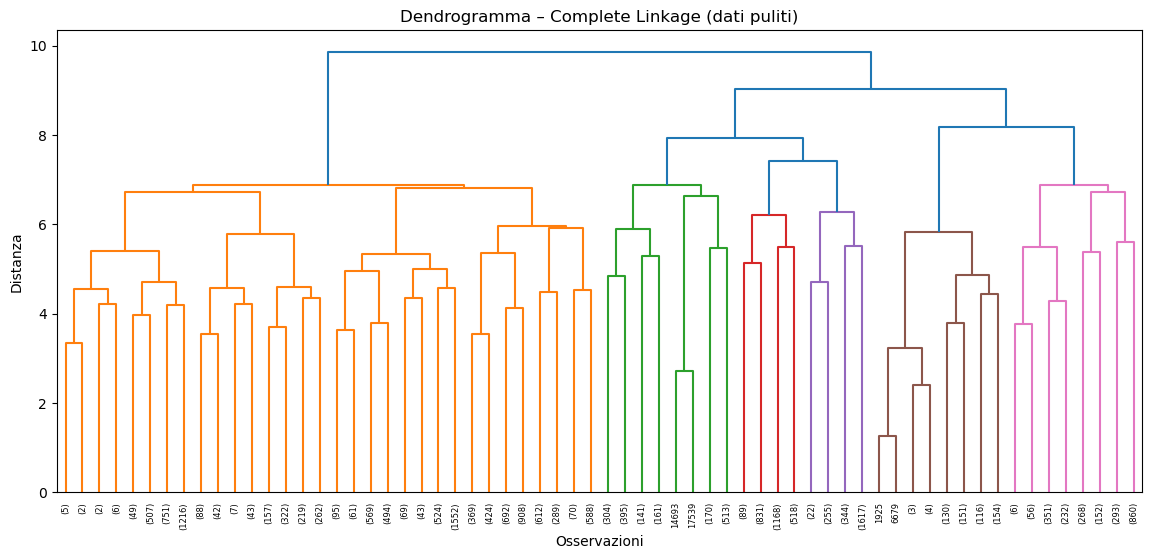

In [58]:
Z_clean_complete = linkage(X_clean, method='complete')

plt.figure(figsize=(14, 6))
dendrogram(Z_clean_complete, truncate_mode='level', p=5)
plt.title("Dendrogramma – Complete Linkage (dati puliti)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()

In [59]:
from sklearn.metrics import silhouette_score

sil_scores_clean_complete = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_clean_complete, t=k, criterion='maxclust')
    score = silhouette_score(X_clean, clusters_k)
    sil_scores_clean_complete[k] = score

sil_scores_clean_complete


{2: np.float64(0.1969333250030849),
 3: np.float64(0.16364905353940082),
 4: np.float64(0.1403023319649223),
 5: np.float64(0.13987786349780246),
 6: np.float64(0.11244935241620277),
 7: np.float64(0.08386873857819069),
 8: np.float64(0.08231630454980673),
 9: np.float64(0.07710783355728965),
 10: np.float64(0.10974919972462005)}

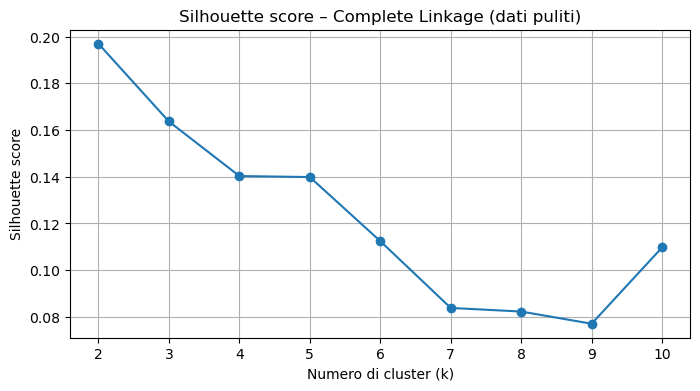

In [60]:
plt.figure(figsize=(8, 4))
plt.plot(list(sil_scores_clean_complete.keys()),
         list(sil_scores_clean_complete.values()),
         marker='o')

plt.title("Silhouette score – Complete Linkage (dati puliti)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [61]:
best_k = max(sil_scores_clean_complete, key=sil_scores_clean_complete.get)
best_k


2

In [62]:
clusters_best = fcluster(Z_clean_complete, t=best_k, criterion="maxclust")
pd.Series(clusters_best).value_counts()


1    11037
2     9308
Name: count, dtype: int64

## Changing again the Preprocessing

Number of rows to remove as outliers: 1094
Data shape: (20785, 10), Features: ['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'EngagementLevel']


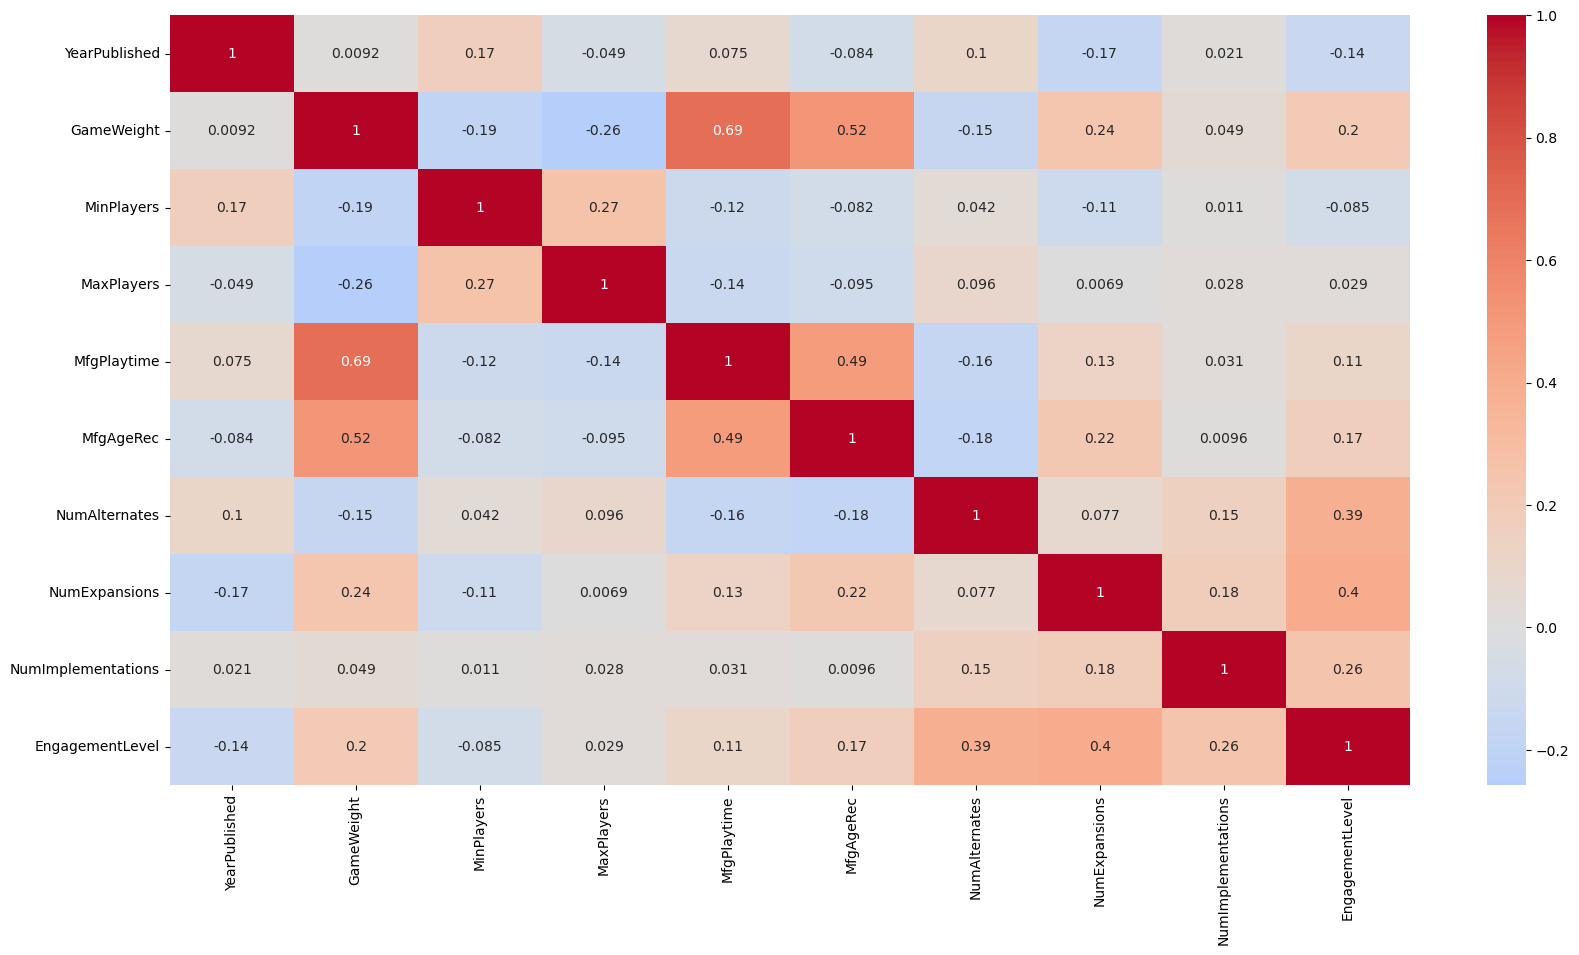

In [3]:
# Select numeric columns and drop missing values
df_num = df.select_dtypes(include=['float64', 'int64'])
# exclude binary columns
numeric_cols = [col for col in df_num.columns if df_num[col].nunique() > 2] 
# exclude rank
numeric_cols = [col for col in numeric_cols if 'Rank' not in col]

# modifying yearpublished using max year - yearpublished (handling games < 0)
if 'YearPublished' in numeric_cols:
    max_year = df_num['YearPublished'].max()
    df_num['YearPublished'] = max_year - df_num['YearPublished']    

df_num = df_num[numeric_cols]

# skewness correction using log1p
for col in df_num.columns:
    if df_num[col].skew() > 1:
        df_num[col] = np.log1p(df_num[col])
    if df_num[col].skew() < -1:
        df_num[col] = np.log1p(df_num[col].max() - df_num[col] + 1)

# removing outliers in multidimensional space using percentile method
outlier_fraction = 0.05  # top 5% as outliers
dists = np.linalg.norm(df_num - df_num.mean(), axis=1) # Euclidean distance from the mean
threshold = np.percentile(dists, 100 * (1 - outlier_fraction)) # threshold distance
rows_to_remove = np.where(dists > threshold)[0] # indices of outlier rows
print(f"Number of rows to remove as outliers: {len(rows_to_remove)}")
df_num = df_num.drop(index=rows_to_remove).reset_index(drop=True)


# verifying correlations

corr = df_num.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)

# final data matrix
X = df_num.values

print(f"Data shape: {X.shape}, Features: {df_num.columns.tolist()}")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Complete Linkage

In [4]:
Z_complete_clean = linkage(X_scaled, method="complete")


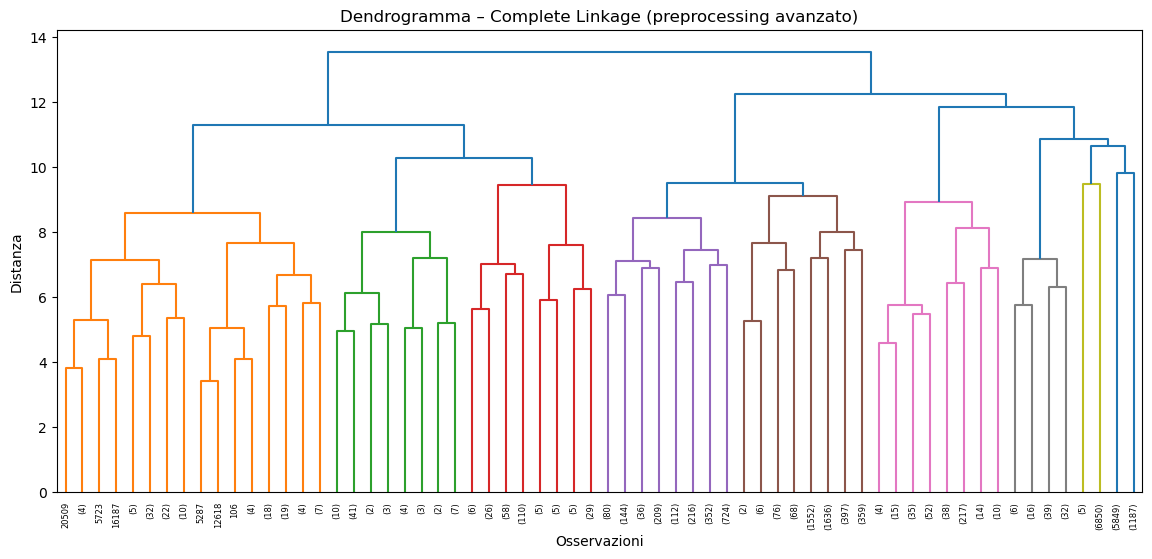

In [5]:
plt.figure(figsize=(14, 6))
dendrogram(Z_complete_clean, truncate_mode='level', p=5)
plt.title("Dendrogramma – Complete Linkage (preprocessing avanzato)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [7]:
from sklearn.metrics import silhouette_score

sil_scores_complete_clean = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_complete_clean, t=k, criterion="maxclust")
    sil = silhouette_score(X_scaled, clusters_k)
    sil_scores_complete_clean[k] = sil

sil_scores_complete_clean


{2: np.float64(0.2993619466535723),
 3: np.float64(0.14185266283905593),
 4: np.float64(0.1289418188975486),
 5: np.float64(0.12517389017839572),
 6: np.float64(0.12662870064909837),
 7: np.float64(0.04798625877260744),
 8: np.float64(0.04302639071867646),
 9: np.float64(0.03585055507671534),
 10: np.float64(0.04112661537785648)}

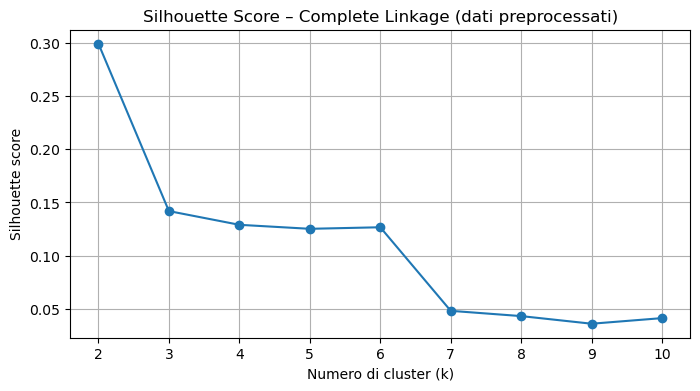

In [8]:
plt.figure(figsize=(8,4))
plt.plot(list(sil_scores_complete_clean.keys()),
         list(sil_scores_complete_clean.values()),
         marker='o')

plt.title("Silhouette Score – Complete Linkage (dati preprocessati)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [9]:
best_k = max(sil_scores_complete_clean, key=sil_scores_complete_clean.get)
best_k


2

In [10]:
clusters_best = fcluster(Z_complete_clean, t=best_k, criterion="maxclust")
pd.Series(clusters_best).value_counts()


2    20338
1      447
Name: count, dtype: int64

# Another Try - Being stricter with outliers

Number of rows to remove as outliers: 2188
Data shape: (19691, 10), Features: ['YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers', 'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'EngagementLevel']


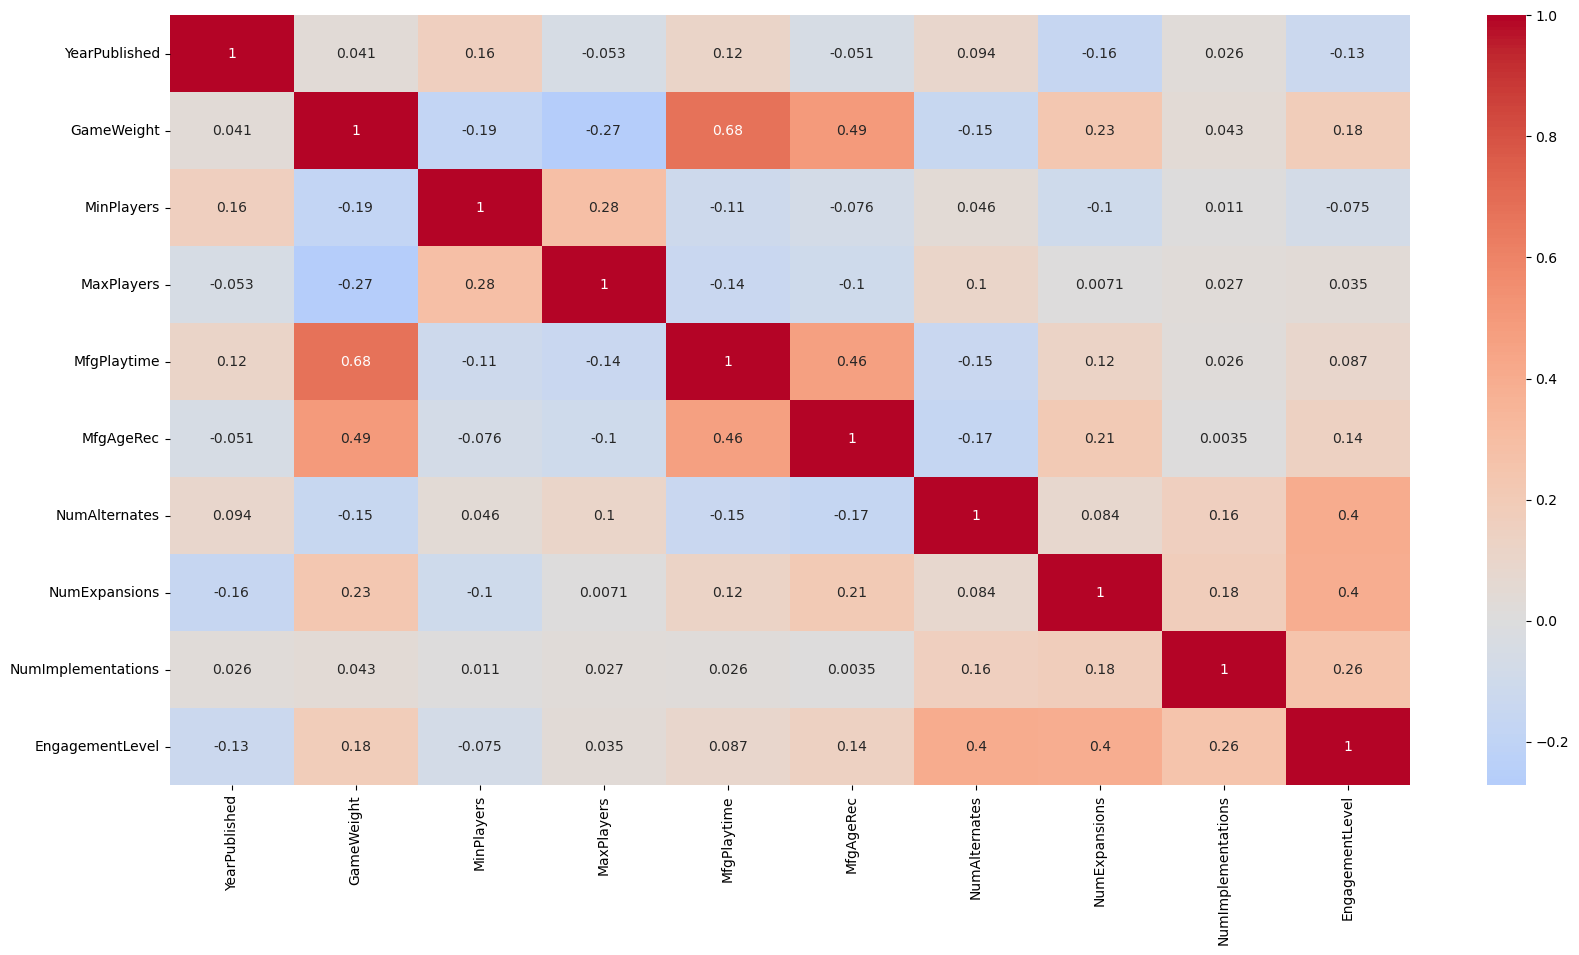

In [11]:
# Select numeric columns and drop missing values
df_num = df.select_dtypes(include=['float64', 'int64'])
# exclude binary columns
numeric_cols = [col for col in df_num.columns if df_num[col].nunique() > 2] 
# exclude rank
numeric_cols = [col for col in numeric_cols if 'Rank' not in col]

# modifying yearpublished using max year - yearpublished (handling games < 0)
if 'YearPublished' in numeric_cols:
    max_year = df_num['YearPublished'].max()
    df_num['YearPublished'] = max_year - df_num['YearPublished']    

df_num = df_num[numeric_cols]

# skewness correction using log1p
for col in df_num.columns:
    sk = df_num[col].skew()
    if sk > 1:   # strongly right-skewed
        df_num[col] = np.log1p(df_num[col])
    elif sk < -1:  # strongly left-skewed
        df_num[col] = np.log1p(df_num[col].max() - df_num[col] + 1)

# removing outliers in multidimensional space using percentile method
outlier_fraction = 0.10  
center = df_num.median(axis=0).values
dists = np.linalg.norm(df_num.values - center, axis=1)

threshold = np.percentile(dists, 100 * (1 - outlier_fraction))
rows_to_remove = np.where(dists > threshold)[0]

print(f"Number of rows to remove as outliers: {len(rows_to_remove)}")

df_num = df_num.drop(index=df_num.index[rows_to_remove]).reset_index(drop=True)


# verifying correlations

corr = df_num.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)

# final data matrix
X = df_num.values

print(f"Data shape: {X.shape}, Features: {df_num.columns.tolist()}")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Complete Linkage Again 

In [12]:
Z_complete_clean = linkage(X_scaled, method="complete")


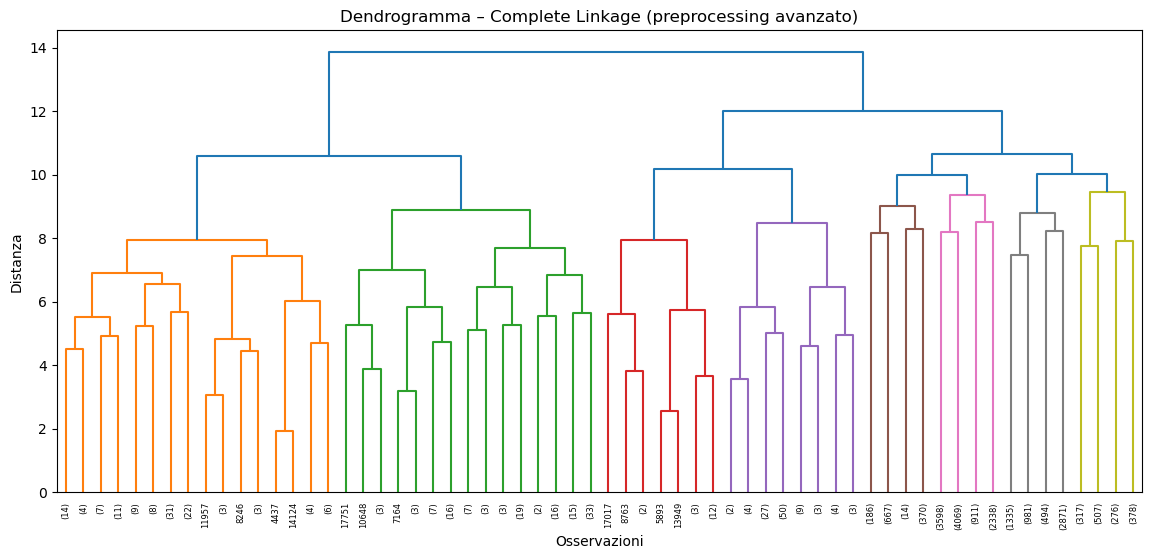

In [13]:
plt.figure(figsize=(14, 6))
dendrogram(Z_complete_clean, truncate_mode='level', p=5)
plt.title("Dendrogramma – Complete Linkage (preprocessing avanzato)")
plt.xlabel("Osservazioni")
plt.ylabel("Distanza")
plt.show()


In [14]:
from sklearn.metrics import silhouette_score

sil_scores_complete_clean = {}

for k in range(2, 11):
    clusters_k = fcluster(Z_complete_clean, t=k, criterion="maxclust")
    sil = silhouette_score(X_scaled, clusters_k)
    sil_scores_complete_clean[k] = sil

sil_scores_complete_clean

{2: np.float64(0.35662515478952833),
 3: np.float64(0.28831206942270843),
 4: np.float64(0.1305939007996722),
 5: np.float64(0.12788271194093756),
 6: np.float64(0.12348960124545977),
 7: np.float64(0.11210667742511521),
 8: np.float64(0.09855943709932002),
 9: np.float64(0.0926800810819035),
 10: np.float64(0.04357560831623962)}

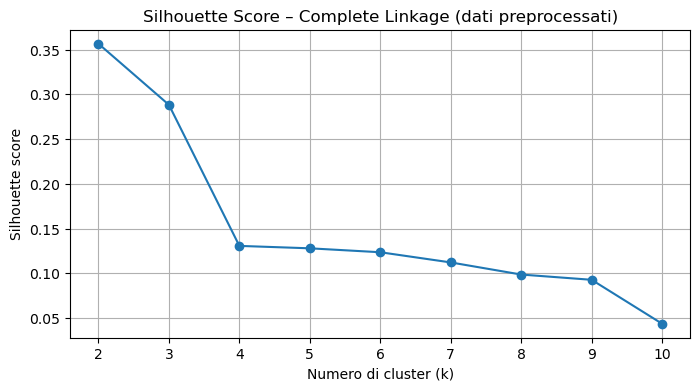

In [15]:
plt.figure(figsize=(8,4))
plt.plot(list(sil_scores_complete_clean.keys()),
         list(sil_scores_complete_clean.values()),
         marker='o')

plt.title("Silhouette Score – Complete Linkage (dati preprocessati)")
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

In [16]:
best_k = max(sil_scores_complete_clean, key=sil_scores_complete_clean.get)
best_k


2

In [17]:
clusters_best = fcluster(Z_complete_clean, t=best_k, criterion="maxclust")
pd.Series(clusters_best).value_counts()

2    19435
1      256
Name: count, dtype: int64